In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    pearsonr,
    spearmanr,
    ttest_ind,
    f_oneway,
    chi2_contingency
)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples
)
from sklearn.decomposition import PCA

from IPython.display import display, Markdown

# Reproducibility
RANDOM_STATE = 42

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# CELL 2 — LOAD DATASET
# ============================================================

# Google Colab:
# Upload shopping_trends(1).csv using the Files panel if needed.

FILE_PATH = "/content/shopping_trends.csv"

# If the exact filename is different, automatically search /content
if not os.path.exists(FILE_PATH):

    csv_files = [
        f for f in os.listdir("/content")
        if f.lower().endswith(".csv")
    ]

    if len(csv_files) == 0:
        raise FileNotFoundError(
            "No CSV file found in /content. "
            "Upload the dataset first."
        )

    # Prefer shopping_trends file
    matching = [
        f for f in csv_files
        if "shopping" in f.lower()
    ]

    if matching:
        FILE_PATH = os.path.join("/content", matching[0])
    else:
        FILE_PATH = os.path.join("/content", csv_files[0])

print("Loading:", FILE_PATH)

df = pd.read_csv(FILE_PATH)

print("\nDataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Loading: /content/shopping_trends.csv

Dataset loaded successfully.
Shape: (3900, 19)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
# ============================================================
# CELL 3 — BASIC DATASET INFORMATION
# ============================================================

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:2}. {col}")

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset information:")
df.info()

DATASET INFORMATION

Number of rows: 3900
Number of columns: 19

Column names:
 1. Customer ID
 2. Age
 3. Gender
 4. Item Purchased
 5. Category
 6. Purchase Amount (USD)
 7. Location
 8. Size
 9. Color
10. Season
11. Review Rating
12. Subscription Status
13. Payment Method
14. Shipping Type
15. Discount Applied
16. Promo Code Used
17. Previous Purchases
18. Preferred Payment Method
19. Frequency of Purchases

Data types:


,Data Type
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object



First 5 rows:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually



Last 5 rows:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Bank Transfer,Store Pickup,No,No,33,Venmo,Quarterly



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null  

In [4]:
# ============================================================
# CELL 3 — BASIC DATASET INFORMATION
# ============================================================

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:2}. {col}")

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset information:")
df.info()

DATASET INFORMATION

Number of rows: 3900
Number of columns: 19

Column names:
 1. Customer ID
 2. Age
 3. Gender
 4. Item Purchased
 5. Category
 6. Purchase Amount (USD)
 7. Location
 8. Size
 9. Color
10. Season
11. Review Rating
12. Subscription Status
13. Payment Method
14. Shipping Type
15. Discount Applied
16. Promo Code Used
17. Previous Purchases
18. Preferred Payment Method
19. Frequency of Purchases

Data types:


,Data Type
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object



First 5 rows:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually



Last 5 rows:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Bank Transfer,Store Pickup,No,No,33,Venmo,Quarterly



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null  

In [5]:
# ============================================================
# CELL 4 — MISSING VALUE ANALYSIS
# ============================================================

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage
}).sort_values(
    "Missing Values",
    ascending=False
)

print("=" * 70)
print("MISSING VALUE ANALYSIS")
print("=" * 70)

display(missing_table)

if missing_count.sum() == 0:
    print("\nRESULT: No missing values found.")
else:
    print(
        f"\nRESULT: {missing_count.sum()} missing values found."
    )

MISSING VALUE ANALYSIS


,Missing Values,Missing Percentage
Customer ID,0,0.0
Age,0,0.0
Gender,0,0.0
Item Purchased,0,0.0
Category,0,0.0
Purchase Amount (USD),0,0.0
Location,0,0.0
Size,0,0.0
Color,0,0.0
Season,0,0.0



RESULT: No missing values found.


In [6]:
# ============================================================
# CELL 6 — VARIABLE TYPES
# ============================================================

numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("=" * 70)
print("NUMERICAL VARIABLES")
print("=" * 70)

print(numerical_columns)

print("\n" + "=" * 70)
print("CATEGORICAL VARIABLES")
print("=" * 70)

print(categorical_columns)

NUMERICAL VARIABLES
['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

CATEGORICAL VARIABLES
['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Subscription Status', 'Payment Method', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Preferred Payment Method', 'Frequency of Purchases']


In [7]:
# ============================================================
# CELL 7 — SELECT ANALYSIS VARIABLES
# ============================================================

# These are the numerical customer-level variables selected
# for the primary clustering analysis.

CLUSTER_FEATURES = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]

# Identifier — never use as a clustering feature
ID_COLUMNS = [
    "Customer ID"
]

# Main statistical outcome
TARGET_VARIABLE = "Purchase Amount (USD)"

# Check that required columns exist
missing_required = [
    col for col in CLUSTER_FEATURES + ID_COLUMNS
    if col not in df.columns
]

if missing_required:
    raise ValueError(
        f"Required columns not found: {missing_required}"
    )

print("=" * 70)
print("SELECTED CLUSTERING FEATURES")
print("=" * 70)

for col in CLUSTER_FEATURES:
    print("-", col)

print("\nExcluded identifier columns:")
for col in ID_COLUMNS:
    print("-", col)

print("\nStatistical outcome variable:")
print("-", TARGET_VARIABLE)

SELECTED CLUSTERING FEATURES
- Age
- Purchase Amount (USD)
- Review Rating
- Previous Purchases

Excluded identifier columns:
- Customer ID

Statistical outcome variable:
- Purchase Amount (USD)


In [8]:
# ============================================================
# CELL 8 — FEATURE SELECTION SUMMARY
# ============================================================

feature_reason_table = pd.DataFrame({
    "Variable": CLUSTER_FEATURES,
    "Role": [
        "Demographic feature",
        "Spending behaviour",
        "Customer satisfaction indicator",
        "Purchase history"
    ],
    "Reason": [
        "Represents customer age",
        "Direct measure of customer spending",
        "Represents customer evaluation of purchases",
        "Represents historical purchasing activity"
    ]
})

display(feature_reason_table)

,Variable,Role,Reason
0,Age,Demographic feature,Represents customer age
1,Purchase Amount (USD),Spending behaviour,Direct measure of customer spending
2,Review Rating,Customer satisfaction indicator,Represents customer evaluation of purchases
3,Previous Purchases,Purchase history,Represents historical purchasing activity


In [9]:
# ============================================================
# CELL 9 — DESCRIPTIVE STATISTICS
# ============================================================

print("=" * 70)
print("DESCRIPTIVE STATISTICS — ORIGINAL DATASET")
print("=" * 70)

descriptive_stats = df[CLUSTER_FEATURES].describe().T

descriptive_stats["median"] = df[
    CLUSTER_FEATURES
].median()

display(descriptive_stats)

DESCRIPTIVE STATISTICS — ORIGINAL DATASET


,count,mean,std,min,25%,50%,75%,max,median
Age,3900.0,44.068462,15.207589,18.0,31.0,44.0,57.0,70.0,44.0
Purchase Amount (USD),3900.0,59.764359,23.685392,20.0,39.0,60.0,81.0,100.0,60.0
Review Rating,3900.0,3.749949,0.716223,2.5,3.1,3.7,4.4,5.0,3.7
Previous Purchases,3900.0,25.351538,14.447125,1.0,13.0,25.0,38.0,50.0,25.0


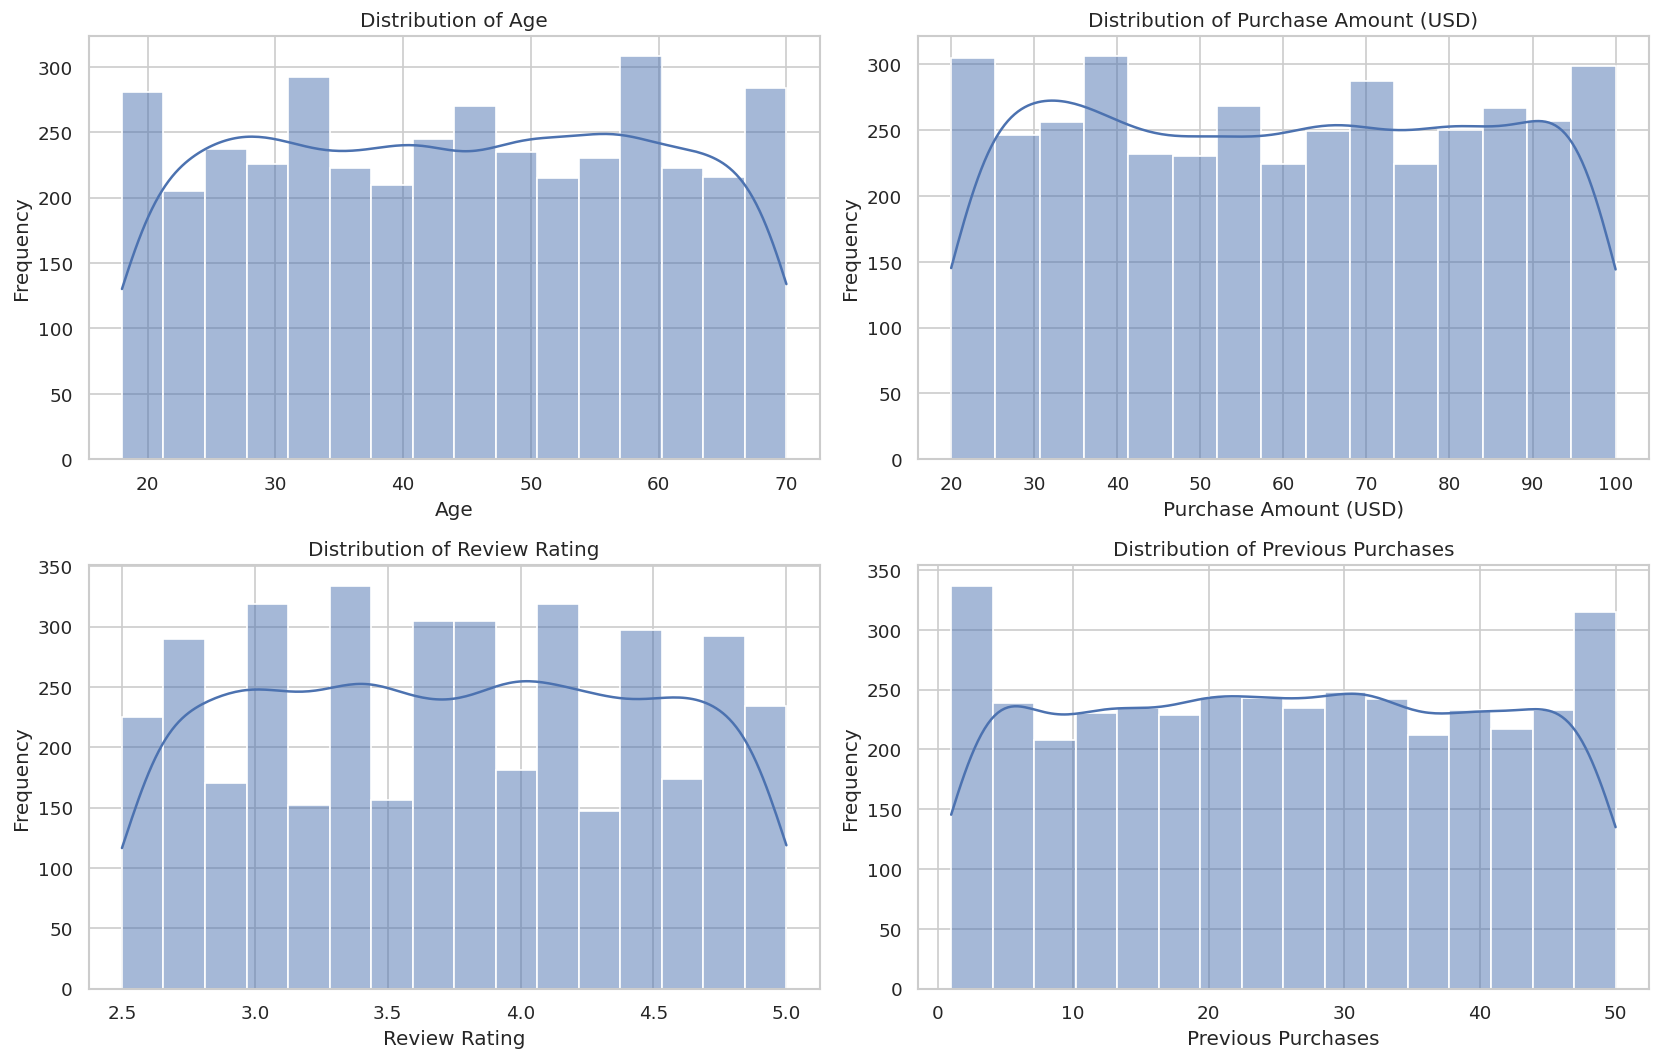

In [11]:
# ============================================================
# CELL 10 — DISTRIBUTIONS
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 9)
)

for ax, col in zip(axes.flatten(), CLUSTER_FEATURES):

    sns.histplot(
        df[col],
        kde=True,
        ax=ax
    )

    ax.set_title(
        f"Distribution of {col}"
    )

    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

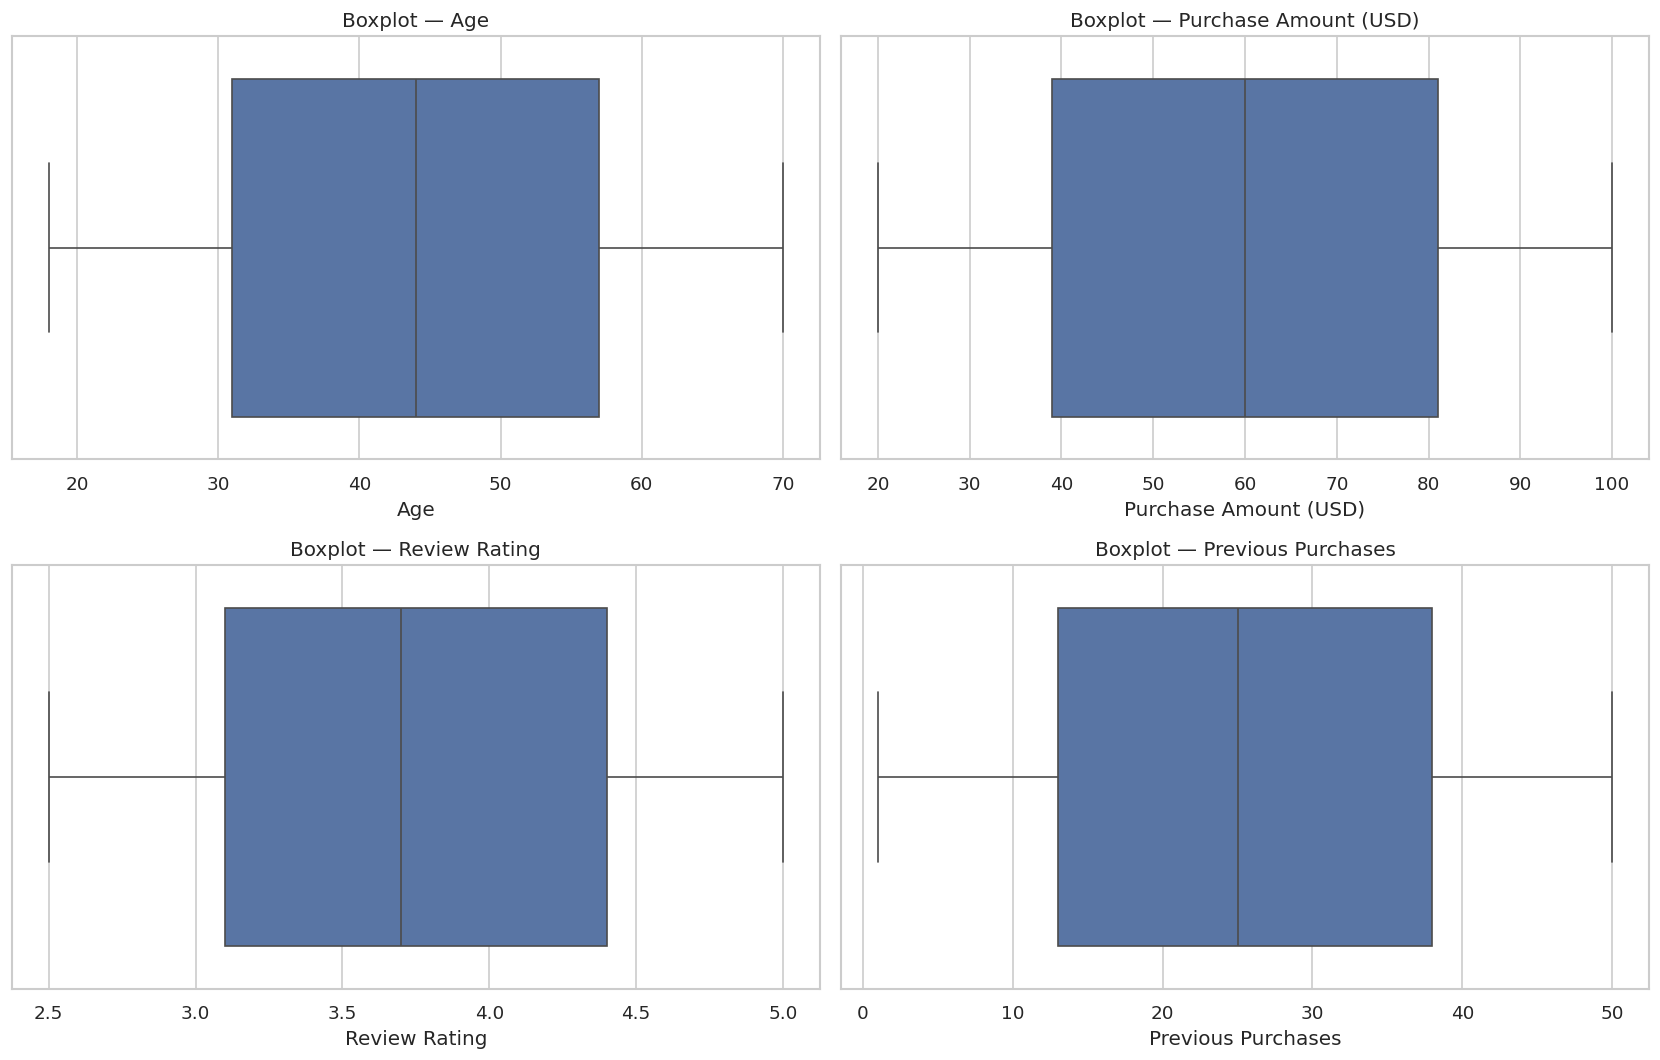

In [12]:
# ============================================================
# CELL 11 — BOXPLOTS
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 9)
)

for ax, col in zip(axes.flatten(), CLUSTER_FEATURES):

    sns.boxplot(
        x=df[col],
        ax=ax
    )

    ax.set_title(
        f"Boxplot — {col}"
    )

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# CELL 12 — IQR OUTLIER ANALYSIS
# ============================================================

outlier_results = []

for col in CLUSTER_FEATURES:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    outlier_percentage = (
        outlier_count / len(df)
    ) * 100

    outlier_results.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage": outlier_percentage
    })

outlier_table = pd.DataFrame(
    outlier_results
)

print("=" * 70)
print("OUTLIER ANALYSIS — IQR METHOD")
print("=" * 70)

display(outlier_table)

print(
    "\nDecision: Observations will NOT be automatically deleted "
    "solely because they are statistical outliers."
)

OUTLIER ANALYSIS — IQR METHOD


,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Age,31.0,57.0,26.0,-8.00,96.00,0,0.0
1,Purchase Amount (USD),39.0,81.0,42.0,-24.00,144.00,0,0.0
2,Review Rating,3.1,4.4,1.3,1.15,6.35,0,0.0
3,Previous Purchases,13.0,38.0,25.0,-24.50,75.50,0,0.0



Decision: Observations will NOT be automatically deleted solely because they are statistical outliers.


In [14]:
# ============================================================
# CELL 13 — RANDOM SAMPLE FOR CLUSTERING
# ============================================================

ORIGINAL_SIZE = len(df)

MAX_SAMPLE_SIZE = 3000

if ORIGINAL_SIZE > MAX_SAMPLE_SIZE:

    analysis_df = df.sample(
        n=MAX_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    ).copy()

    sampling_method = (
        "Random sampling without replacement"
    )

else:

    analysis_df = df.copy()

    sampling_method = (
        "Full dataset used because size <= 3,000"
    )

SAMPLE_SIZE = len(analysis_df)

print("=" * 70)
print("SAMPLING")
print("=" * 70)

print("Original dataset size:", ORIGINAL_SIZE)
print("Analysis sample size:", SAMPLE_SIZE)
print("Sampling method:", sampling_method)
print("Random state:", RANDOM_STATE)

SAMPLING
Original dataset size: 3900
Analysis sample size: 3000
Sampling method: Random sampling without replacement
Random state: 42


In [15]:
# ============================================================
# CELL 14 — ORIGINAL VS SAMPLE DISTRIBUTIONS
# ============================================================

comparison_rows = []

for col in CLUSTER_FEATURES:

    comparison_rows.append({
        "Variable": col,

        "Original Mean": df[col].mean(),
        "Sample Mean": analysis_df[col].mean(),

        "Original Std": df[col].std(),
        "Sample Std": analysis_df[col].std(),

        "Original Median": df[col].median(),
        "Sample Median": analysis_df[col].median()
    })

sampling_comparison = pd.DataFrame(
    comparison_rows
)

display(sampling_comparison)

,Variable,Original Mean,Sample Mean,Original Std,Sample Std,Original Median,Sample Median
0,Age,44.068462,43.993000,15.207589,15.228118,44.0,44.0
1,Purchase Amount (USD),59.764359,59.846667,23.685392,23.758198,60.0,60.0
2,Review Rating,3.749949,3.747933,0.716223,0.716366,3.7,3.7
3,Previous Purchases,25.351538,25.365667,14.447125,14.475282,25.0,25.0


PEARSON CORRELATION MATRIX


,Age,Purchase Amount (USD),Review Rating,Previous Purchases
Age,1.000000,-0.015829,-0.013363,0.048015
Purchase Amount (USD),-0.015829,1.000000,0.028219,0.001034
Review Rating,-0.013363,0.028219,1.000000,-0.001038
Previous Purchases,0.048015,0.001034,-0.001038,1.000000


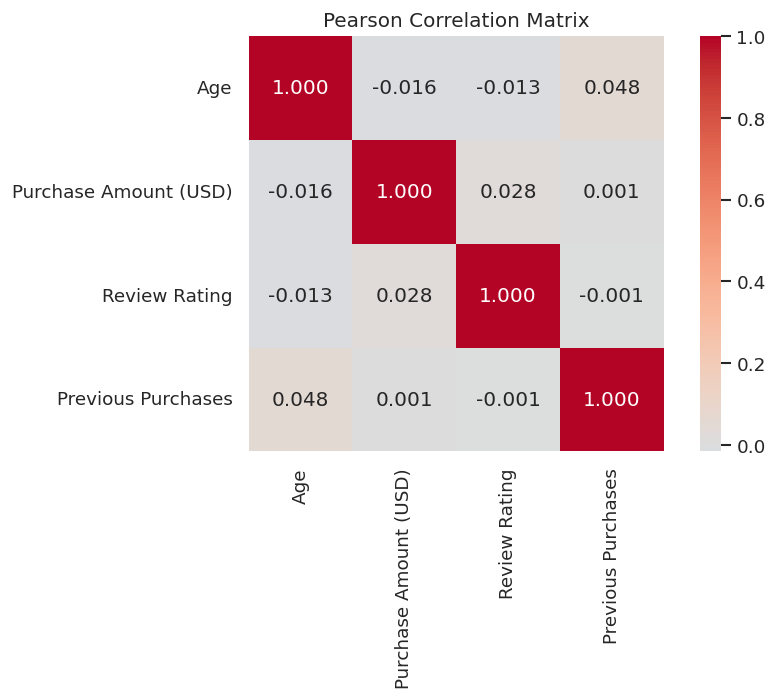

In [16]:
# ============================================================
# CELL 15 — PEARSON CORRELATION
# ============================================================

pearson_corr = analysis_df[
    CLUSTER_FEATURES
].corr(method="pearson")

print("=" * 70)
print("PEARSON CORRELATION MATRIX")
print("=" * 70)

display(pearson_corr)

plt.figure(figsize=(8, 6))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Pearson Correlation Matrix"
)

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# CELL 16 — PEARSON CORRELATION + P-VALUES
# ============================================================

correlation_results = []

for col in CLUSTER_FEATURES:

    if col == TARGET_VARIABLE:
        continue

    r, p = pearsonr(
        analysis_df[col],
        analysis_df[TARGET_VARIABLE]
    )

    correlation_results.append({
        "Predictor": col,
        "Pearson r": r,
        "p-value": p,
        "Significant (α=0.05)": (
            "Yes" if p < 0.05 else "No"
        )
    })

pearson_results = pd.DataFrame(
    correlation_results
)

display(pearson_results)

,Predictor,Pearson r,p-value,Significant (α=0.05)
0,Age,-0.015829,0.386102,No
1,Review Rating,0.028219,0.122277,No
2,Previous Purchases,0.001034,0.954865,No


In [18]:
# ============================================================
# CELL 20 — CHI-SQUARE TEST
# ============================================================

categorical_pair_1 = "Discount Applied"
categorical_pair_2 = "Subscription Status"

contingency_table = pd.crosstab(
    analysis_df[categorical_pair_1],
    analysis_df[categorical_pair_2]
)

print("=" * 70)
print("CHI-SQUARE TEST")
print("=" * 70)

print(
    f"\nTesting association between "
    f"{categorical_pair_1} and {categorical_pair_2}"
)

display(contingency_table)

chi2, p, dof, expected = chi2_contingency(
    contingency_table
)

print("\nChi-square statistic:", round(chi2, 4))
print("Degrees of freedom:", dof)
print("p-value:", round(p, 4))

if p < 0.05:
    print(
        "Conclusion: Significant association "
        "at α = 0.05."
    )
else:
    print(
        "Conclusion: No statistically significant "
        "association at α = 0.05."
    )

CHI-SQUARE TEST

Testing association between Discount Applied and Subscription Status


Subscription Status,No,Yes
Discount Applied,,
No,1703,0
Yes,474,823



Chi-square statistic: 1485.9604
Degrees of freedom: 1
p-value: 0.0
Conclusion: Significant association at α = 0.05.


In [19]:
# ============================================================
# CELL 21 — PREPARE CLUSTERING FEATURES
# ============================================================

X = analysis_df[
    CLUSTER_FEATURES
].copy()

print("Clustering matrix shape:", X.shape)

display(X.head())

Clustering matrix shape: (3000, 4)


,Age,Purchase Amount (USD),Review Rating,Previous Purchases
839,48,31,2.6,10
1717,29,50,2.9,16
321,41,36,4.7,48
3187,67,72,3.2,28
2269,49,38,4.4,27


In [20]:
# ============================================================
# CELL 22 — STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=CLUSTER_FEATURES,
    index=X.index
)

print("=" * 70)
print("STANDARDIZED FEATURES")
print("=" * 70)

display(X_scaled_df.head())

print("\nMeans after scaling:")
display(
    X_scaled_df.mean().round(4)
)

print("\nStandard deviations after scaling:")
display(
    X_scaled_df.std().round(4)
)

STANDARDIZED FEATURES


,Age,Purchase Amount (USD),Review Rating,Previous Purchases
839,0.263176,-1.214380,-1.602707,-1.061688
1717,-0.984724,-0.414523,-1.183857,-0.647119
321,-0.196577,-1.003891,1.329244,1.563915
3187,1.511075,0.511628,-0.765007,0.182019
2269,0.328854,-0.919696,0.910394,0.112924



Means after scaling:


,0
Age,-0.0
Purchase Amount (USD),0.0
Review Rating,0.0
Previous Purchases,0.0



Standard deviations after scaling:


,0
Age,1.0002
Purchase Amount (USD),1.0002
Review Rating,1.0002
Previous Purchases,1.0002


,k,Inertia
0,2,9717.843956
1,3,8309.797173
2,4,7189.390920
3,5,6347.788853
4,6,5759.162724
5,7,5174.207902
6,8,4602.101312
7,9,4306.765591
8,10,4045.447348
9,11,3783.583905


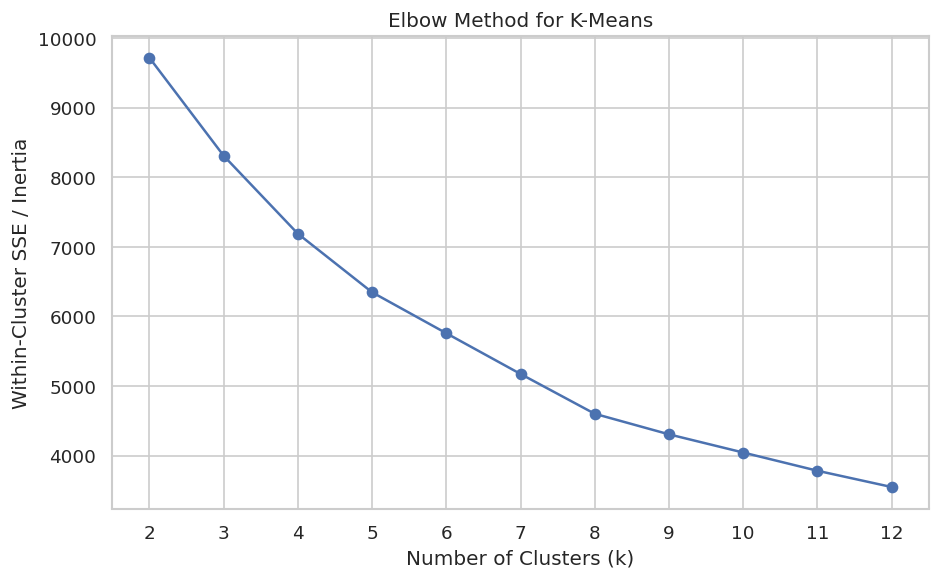

In [21]:
# ============================================================
# CELL 23 — K-MEANS ELBOW METHOD
# ============================================================

K_RANGE = range(2, 13)

inertias = []

for k in K_RANGE:

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    model.fit(X_scaled)

    inertias.append(
        model.inertia_
    )

elbow_results = pd.DataFrame({
    "k": list(K_RANGE),
    "Inertia": inertias
})

display(elbow_results)

plt.figure(figsize=(8, 5))

plt.plot(
    elbow_results["k"],
    elbow_results["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster SSE / Inertia")
plt.title("Elbow Method for K-Means")

plt.xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

,k,Silhouette Score
0,2,0.186588
1,3,0.178272
2,4,0.192865
3,5,0.201390
4,6,0.200773
5,7,0.213140
6,8,0.230451
7,9,0.222937
8,10,0.215942
9,11,0.220288



Best silhouette among tested values: k=8
Silhouette score: 0.2305


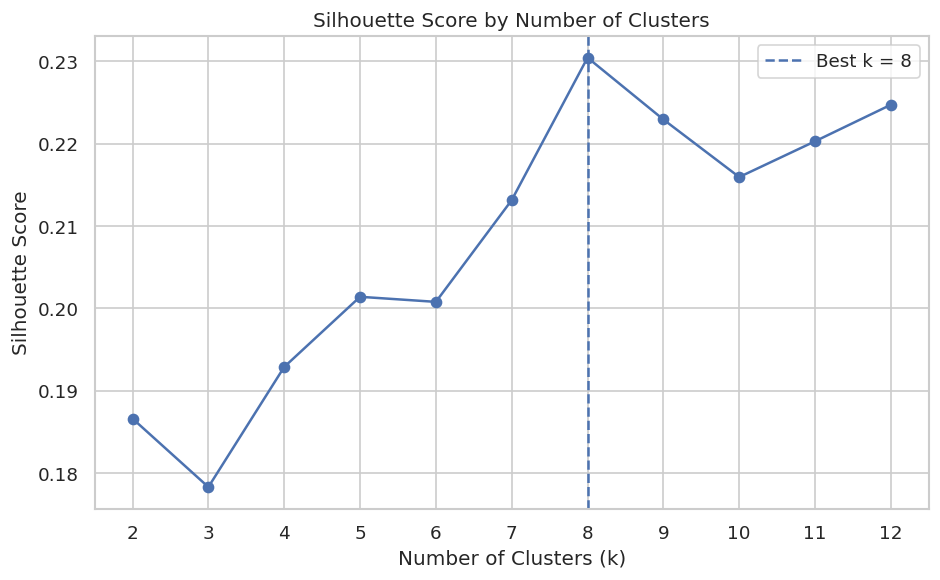

In [22]:
# ============================================================
# CELL 24 — SILHOUETTE ANALYSIS
# ============================================================

silhouette_results = []

for k in K_RANGE:

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = model.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_results.append({
        "k": k,
        "Silhouette Score": score
    })

silhouette_df = pd.DataFrame(
    silhouette_results
)

display(silhouette_df)

best_silhouette_row = silhouette_df.loc[
    silhouette_df["Silhouette Score"].idxmax()
]

BEST_K_SILHOUETTE = int(
    best_silhouette_row["k"]
)

BEST_SILHOUETTE = float(
    best_silhouette_row["Silhouette Score"]
)

print(
    f"\nBest silhouette among tested values: "
    f"k={BEST_K_SILHOUETTE}"
)

print(
    f"Silhouette score: "
    f"{BEST_SILHOUETTE:.4f}"
)

plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_df["k"],
    silhouette_df["Silhouette Score"],
    marker="o"
)

plt.axvline(
    BEST_K_SILHOUETTE,
    linestyle="--",
    label=f"Best k = {BEST_K_SILHOUETTE}"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")

plt.legend()
plt.xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# CELL 25 — FINAL K-MEANS MODEL
# ============================================================

FINAL_K = BEST_K_SILHOUETTE

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(
    X_scaled
)

analysis_df["KMeans_Cluster"] = kmeans_labels

final_kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("=" * 70)
print("FINAL K-MEANS MODEL")
print("=" * 70)

print("Selected k:", FINAL_K)
print(
    "Final Silhouette Score:",
    round(final_kmeans_silhouette, 4)
)

print("\nCluster counts:")

cluster_counts = (
    analysis_df["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

display(
    cluster_counts.to_frame(
        "Number of Customers"
    )
)

FINAL K-MEANS MODEL
Selected k: 8
Final Silhouette Score: 0.2305

Cluster counts:


,Number of Customers
KMeans_Cluster,
0,400
1,353
2,371
3,343
4,396
5,393
6,371
7,373


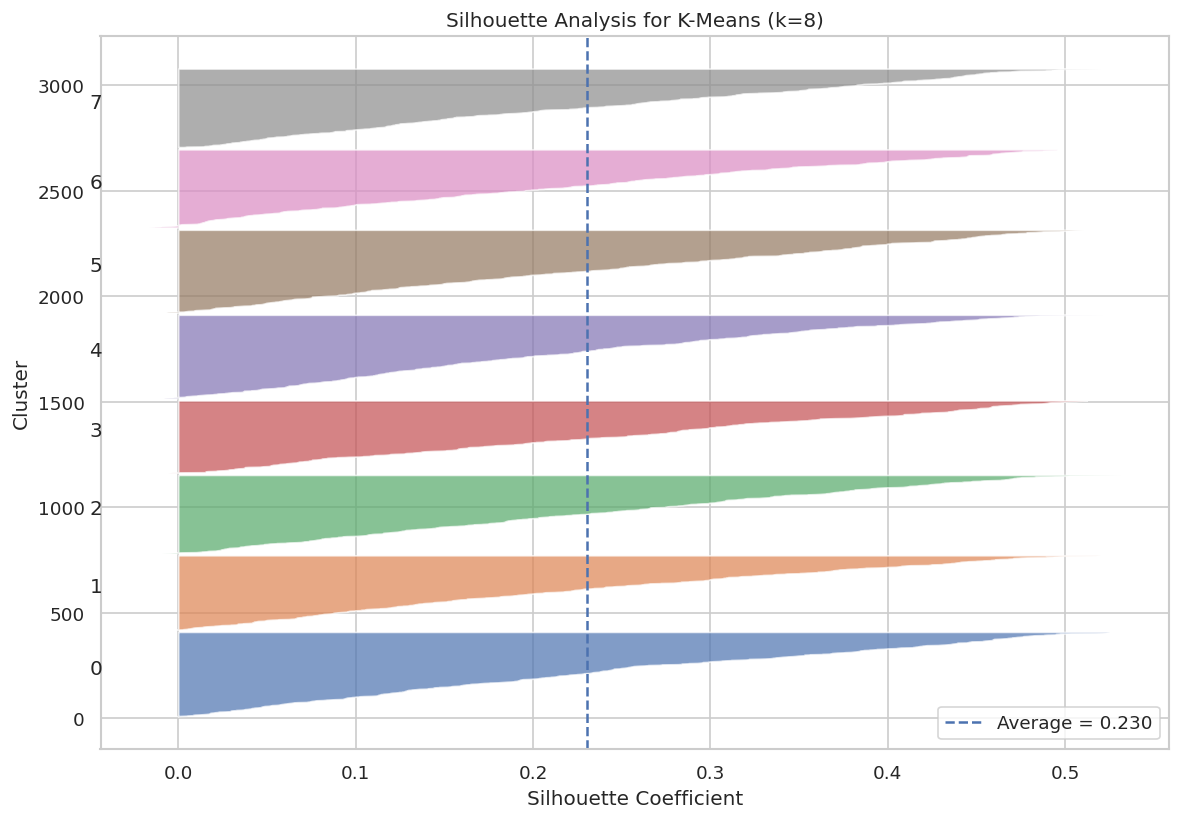

In [24]:
# ============================================================
# CELL 26 — DETAILED SILHOUETTE ANALYSIS
# ============================================================

sample_silhouette_values = silhouette_samples(
    X_scaled,
    kmeans_labels
)

plt.figure(figsize=(10, 7))

y_lower = 10

for i in range(FINAL_K):

    ith_cluster_values = (
        sample_silhouette_values[
            kmeans_labels == i
        ]
    )

    ith_cluster_values.sort()

    size_cluster_i = (
        ith_cluster_values.shape[0]
    )

    y_upper = (
        y_lower +
        size_cluster_i
    )

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_values,
        alpha=0.7
    )

    plt.text(
        -0.05,
        y_lower + 0.5 * size_cluster_i,
        str(i)
    )

    y_lower = y_upper + 10

plt.axvline(
    final_kmeans_silhouette,
    linestyle="--",
    label=f"Average = {final_kmeans_silhouette:.3f}"
)

plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.title(
    f"Silhouette Analysis for K-Means (k={FINAL_K})"
)

plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# CELL 27 — CLUSTER PROFILE TABLE
# ============================================================

cluster_profile = (
    analysis_df
    .groupby("KMeans_Cluster")[CLUSTER_FEATURES]
    .agg([
        "count",
        "mean",
        "median",
        "std"
    ])
)

display(cluster_profile)

Age                              Purchase Amount (USD)  \
               count       mean median        std                 count   
KMeans_Cluster                                                            
0                400  31.897500   31.0   9.539365                   400   
1                353  56.314448   57.0   9.423149                   353   
2                371  56.412399   57.0   9.125536                   371   
3                343  57.326531   58.0   8.399288                   343   
4                396  32.787879   32.0   9.440578                   396   
5                393  32.671756   32.0   9.879201                   393   
6                371  32.644205   31.0  10.047325                   371   
7                373  55.801609   57.0   9.265400                   373   

                                            Review Rating                   \
                     mean median        std         count      mean median   
KMeans_Cluster                                                               
0               78.922500   80.5  13.959537           400  3.228500    3.2   
1               78.311615   80.0  14.679698           353  4.295467    4.3   
2               39.309973   37.0  13.631576           371  4.246361    4.3   
3               80.221574   82.0  14.104369           343  3.331487    3.3   
4               44.878788   43.0  16.234062           396  3.178788    3.1   
5               38.834606   36.0  13.755541           393  4.262595    4.3   
6               79.000000   81.0  14.063947           371  4.413208    4.5   
7               42.584450   41.0  14.357624           373  3.074263    3.0   

                         Previous Purchases                               
                     std              count       mean median        std  
KMeans_Cluster                                                            
0               0.468440                400  13.622500   12.0   8.837434  
1               0.468232                353  13.674221   12.0   8.775860  
2               0.468415                371  36.110512   37.0   8.907098  
3               0.500000                343  38.128280   39.0   8.545091  
4               0.430431                396  37.191919   38.0   8.319782  
5               0.462138                393  13.651399   12.0   9.136332  
6               0.418767                371  35.619946   37.0  10.180986  
7               0.383016                373  16.187668   15.0   9.771704

In [26]:
# ============================================================
# CELL 28 — RESEARCH PAPER CLUSTER PROFILE
# ============================================================

cluster_summary = (
    analysis_df
    .groupby("KMeans_Cluster")
    .agg(
        Customers=("KMeans_Cluster", "size"),
        Mean_Age=("Age", "mean"),
        Mean_Purchase_Amount=(
            "Purchase Amount (USD)",
            "mean"
        ),
        Mean_Review_Rating=(
            "Review Rating",
            "mean"
        ),
        Mean_Previous_Purchases=(
            "Previous Purchases",
            "mean"
        )
    )
    .reset_index()
)

cluster_summary = cluster_summary.round(2)

display(cluster_summary)

,KMeans_Cluster,Customers,Mean_Age,Mean_Purchase_Amount,Mean_Review_Rating,Mean_Previous_Purchases
0,0,400,31.90,78.92,3.23,13.62
1,1,353,56.31,78.31,4.30,13.67
2,2,371,56.41,39.31,4.25,36.11
3,3,343,57.33,80.22,3.33,38.13
4,4,396,32.79,44.88,3.18,37.19
5,5,393,32.67,38.83,4.26,13.65
6,6,371,32.64,79.00,4.41,35.62
7,7,373,55.80,42.58,3.07,16.19


In [27]:
# ============================================================
# CELL 29 — CLUSTER SIZE + PERCENTAGE
# ============================================================

cluster_size_table = (
    analysis_df
    .groupby("KMeans_Cluster")
    .size()
    .reset_index(
        name="Customers"
    )
)

cluster_size_table["Percentage"] = (
    cluster_size_table["Customers"]
    / len(analysis_df)
    * 100
)

cluster_size_table[
    "Percentage"
] = cluster_size_table[
    "Percentage"
].round(2)

display(cluster_size_table)

,KMeans_Cluster,Customers,Percentage
0,0,400,13.33
1,1,353,11.77
2,2,371,12.37
3,3,343,11.43
4,4,396,13.20
5,5,393,13.10
6,6,371,12.37
7,7,373,12.43


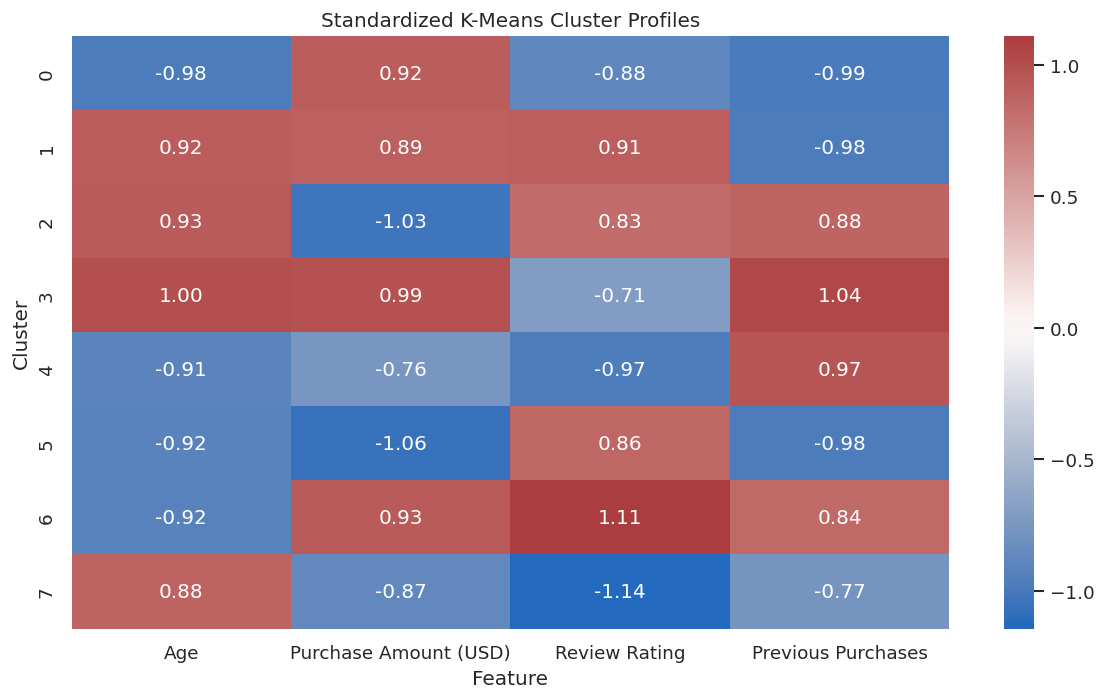

In [28]:
# ============================================================
# CELL 30 — STANDARDIZED CLUSTER PROFILE HEATMAP
# ============================================================

profile_means = (
    analysis_df
    .groupby("KMeans_Cluster")[CLUSTER_FEATURES]
    .mean()
)

# Standardize the cluster means only for visualization
profile_z = (
    profile_means -
    profile_means.mean()
) / profile_means.std()

plt.figure(figsize=(10, 6))

sns.heatmap(
    profile_z,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0
)

plt.title(
    "Standardized K-Means Cluster Profiles"
)

plt.xlabel("Feature")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

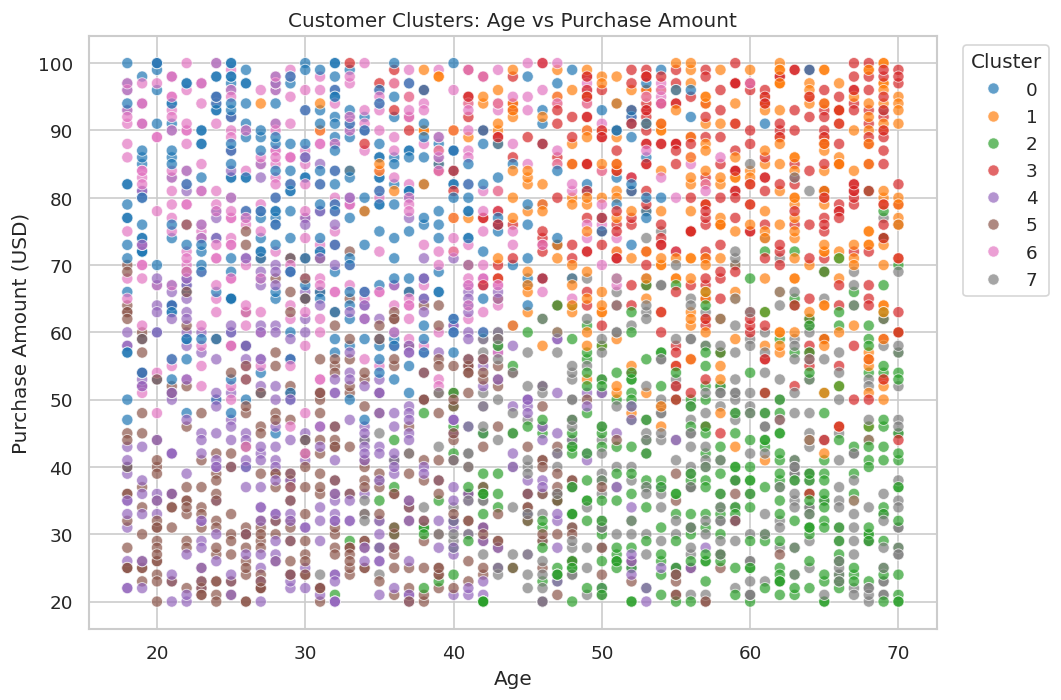

In [29]:
# ============================================================
# CELL 31 — 2D CLUSTER VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=analysis_df,
    x="Age",
    y="Purchase Amount (USD)",
    hue="KMeans_Cluster",
    palette="tab10",
    s=45,
    alpha=0.7
)

plt.title(
    "Customer Clusters: Age vs Purchase Amount"
)

plt.xlabel("Age")
plt.ylabel("Purchase Amount (USD)")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

PCA RESULTS
PC1 explains 26.41% of variance.
PC2 explains 25.57% of variance.
Combined explained variance: 51.98%


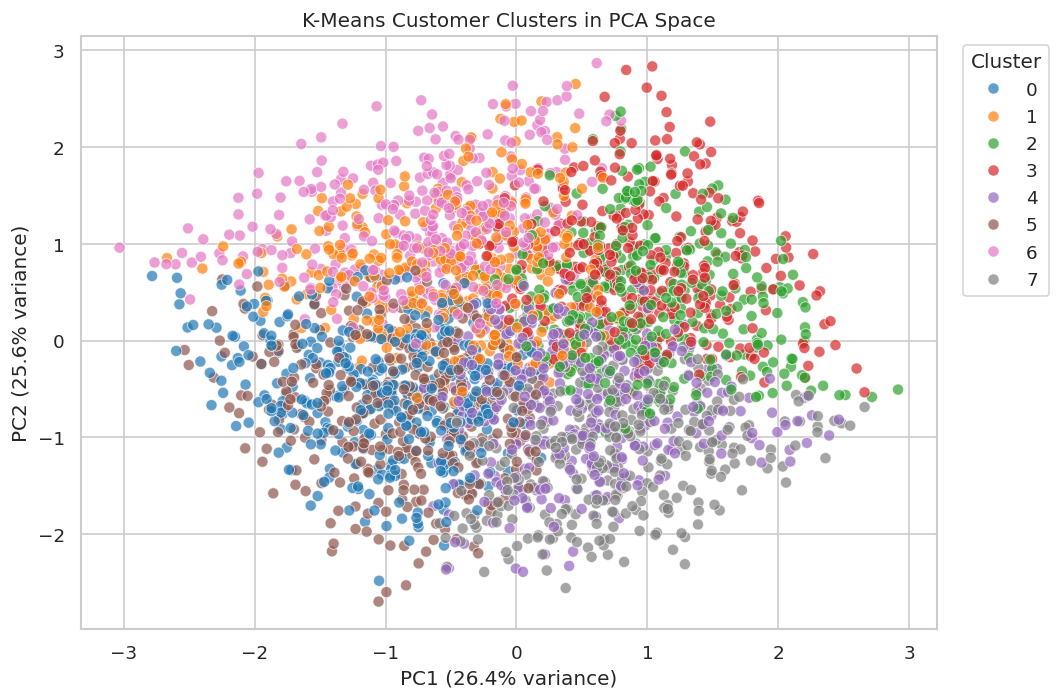

In [30]:
# ============================================================
# CELL 32 — PCA FOR VISUALIZATION
# ============================================================

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": kmeans_labels
})

explained_variance = (
    pca.explained_variance_ratio_
    * 100
)

print("=" * 70)
print("PCA RESULTS")
print("=" * 70)

print(
    f"PC1 explains "
    f"{explained_variance[0]:.2f}% of variance."
)

print(
    f"PC2 explains "
    f"{explained_variance[1]:.2f}% of variance."
)

print(
    f"Combined explained variance: "
    f"{explained_variance.sum():.2f}%"
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=45,
    alpha=0.7
)

plt.title(
    "K-Means Customer Clusters in PCA Space"
)

plt.xlabel(
    f"PC1 ({explained_variance[0]:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1]:.1f}% variance)"
)

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# CELL 33 — PCA LOADINGS
# ============================================================

pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=CLUSTER_FEATURES
)

print("=" * 70)
print("PCA LOADINGS")
print("=" * 70)

display(
    pca_loadings.round(4)
)

PCA LOADINGS


,PC1,PC2
Age,0.6634,0.2243
Purchase Amount (USD),-0.3485,0.6067
Review Rating,-0.3430,0.5983
Previous Purchases,0.5664,0.4729


,k,Silhouette Score
0,2,0.133558
1,3,0.126535
2,4,0.132150
3,5,0.124380
4,6,0.127868
5,7,0.127716
6,8,0.134585
7,9,0.138719
8,10,0.135547
9,11,0.133478



Best hierarchical clustering:
k = 9
Silhouette = 0.1387


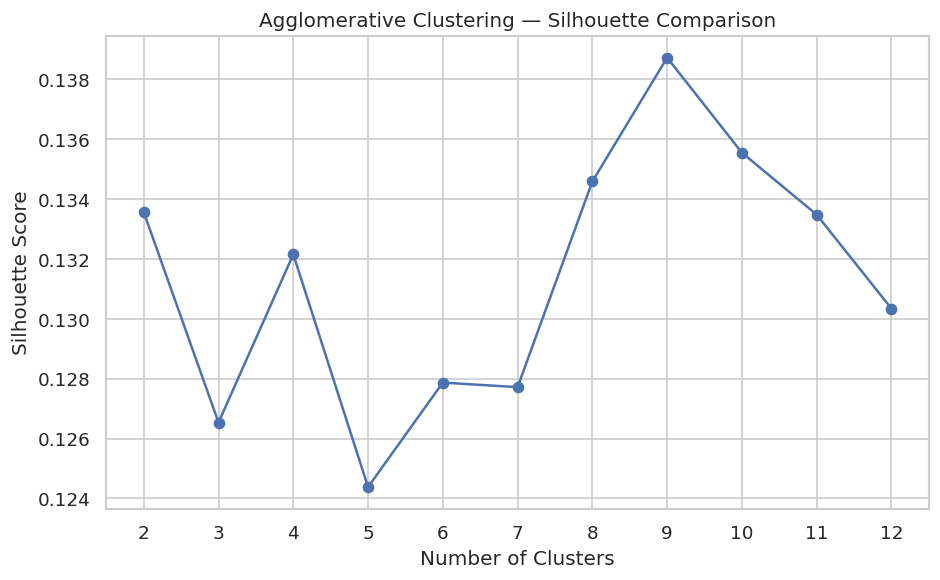

In [32]:
# ============================================================
# CELL 34 — HIERARCHICAL CLUSTERING COMPARISON
# ============================================================

hierarchical_results = []

for k in K_RANGE:

    hierarchical_model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    hierarchical_labels = (
        hierarchical_model.fit_predict(
            X_scaled
        )
    )

    score = silhouette_score(
        X_scaled,
        hierarchical_labels
    )

    hierarchical_results.append({
        "k": k,
        "Silhouette Score": score
    })

hierarchical_df = pd.DataFrame(
    hierarchical_results
)

display(hierarchical_df)

best_hierarchical = hierarchical_df.loc[
    hierarchical_df["Silhouette Score"].idxmax()
]

print(
    "\nBest hierarchical clustering:"
)

print(
    "k =",
    int(best_hierarchical["k"])
)

print(
    "Silhouette =",
    round(
        best_hierarchical["Silhouette Score"],
        4
    )
)

plt.figure(figsize=(8, 5))

plt.plot(
    hierarchical_df["k"],
    hierarchical_df["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title(
    "Agglomerative Clustering — Silhouette Comparison"
)

plt.xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# CELL 35 — CLUSTERING METHOD COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Method": [
        "K-Means",
        "Agglomerative"
    ],
    "Best k": [
        FINAL_K,
        int(best_hierarchical["k"])
    ],
    "Best Silhouette": [
        final_kmeans_silhouette,
        best_hierarchical["Silhouette Score"]
    ]
})

comparison["Best Silhouette"] = (
    comparison["Best Silhouette"]
    .round(4)
)

display(comparison)

,Method,Best k,Best Silhouette
0,K-Means,8,0.2305
1,Agglomerative,9,0.1387


In [34]:
# ============================================================
# CELL 36 — DBSCAN PARAMETER SEARCH
# ============================================================

eps_values = np.arange(
    0.2,
    1.51,
    0.1
)

min_samples_values = [
    3,
    5,
    10
]

dbscan_results = []

for eps in eps_values:

    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(
            X_scaled
        )

        n_clusters = len(
            set(labels)
            - {-1}
        )

        n_noise = np.sum(
            labels == -1
        )

        # Silhouette requires at least 2 actual clusters
        # and excludes DBSCAN noise points.
        non_noise_mask = labels != -1

        if (
            n_clusters >= 2
            and non_noise_mask.sum() > n_clusters
        ):

            try:

                score = silhouette_score(
                    X_scaled[non_noise_mask],
                    labels[non_noise_mask]
                )

            except:
                score = np.nan

        else:
            score = np.nan

        dbscan_results.append({
            "eps": round(eps, 2),
            "min_samples": min_samples,
            "Clusters": n_clusters,
            "Noise Points": n_noise,
            "Silhouette": score
        })

dbscan_df = pd.DataFrame(
    dbscan_results
)

display(
    dbscan_df.sort_values(
        "Silhouette",
        ascending=False
    ).head(15)
)

,eps,min_samples,Clusters,Noise Points,Silhouette
8,0.4,10,2,2980,0.859160
0,0.2,3,17,2946,0.829742
4,0.3,5,17,2907,0.747345
3,0.3,3,229,2105,0.481632
7,0.4,5,136,1516,0.175975
11,0.5,10,43,1573,0.097369
14,0.6,10,2,81,0.035337
6,0.4,3,155,556,-0.248142
10,0.5,5,4,154,-0.258367
9,0.5,3,10,34,-0.302417


In [35]:
# ============================================================
# CELL 37 — DBSCAN DIAGNOSTIC
# ============================================================

valid_dbscan = dbscan_df.dropna(
    subset=["Silhouette"]
).copy()

if len(valid_dbscan) == 0:

    print(
        "DBSCAN did not produce a valid multi-cluster "
        "solution under the tested parameter range."
    )

    dbscan_recommendation = "Not appropriate"

else:

    best_dbscan = valid_dbscan.loc[
        valid_dbscan["Silhouette"].idxmax()
    ]

    print("=" * 70)
    print("BEST DBSCAN RESULT")
    print("=" * 70)

    print(
        "eps:",
        best_dbscan["eps"]
    )

    print(
        "min_samples:",
        int(best_dbscan["min_samples"])
    )

    print(
        "Clusters:",
        int(best_dbscan["Clusters"])
    )

    print(
        "Noise points:",
        int(best_dbscan["Noise Points"])
    )

    print(
        "Silhouette:",
        round(
            best_dbscan["Silhouette"],
            4
        )
    )

    # Compare with K-Means
    if (
        best_dbscan["Silhouette"]
        >
        final_kmeans_silhouette
    ):

        dbscan_recommendation = (
            "DBSCAN produced a higher silhouette "
            "than K-Means in the tested parameter range."
        )

    else:

        dbscan_recommendation = (
            "DBSCAN did not outperform K-Means "
            "in the tested parameter range."
        )

    print("\nRecommendation:")
    print(dbscan_recommendation)

BEST DBSCAN RESULT
eps: 0.4
min_samples: 10
Clusters: 2
Noise points: 2980
Silhouette: 0.8592

Recommendation:
DBSCAN produced a higher silhouette than K-Means in the tested parameter range.


In [36]:
# ============================================================
# CELL 38 — BEST DBSCAN MODEL
# ============================================================

if len(valid_dbscan) > 0:

    best_eps = float(
        best_dbscan["eps"]
    )

    best_min_samples = int(
        best_dbscan["min_samples"]
    )

    dbscan_final = DBSCAN(
        eps=best_eps,
        min_samples=best_min_samples
    )

    dbscan_labels = dbscan_final.fit_predict(
        X_scaled
    )

    analysis_df["DBSCAN_Cluster"] = (
        dbscan_labels
    )

    print(
        "DBSCAN labels created successfully."
    )

    print(
        "\nCluster counts including noise (-1):"
    )

    display(
        analysis_df[
            "DBSCAN_Cluster"
        ]
        .value_counts()
        .sort_index()
        .to_frame("Count")
    )

else:

    print(
        "No usable DBSCAN solution was found."
    )

DBSCAN labels created successfully.

Cluster counts including noise (-1):


,Count
DBSCAN_Cluster,
-1,2980
0,10
1,10


In [37]:
# ============================================================
# CELL 39 — FINAL MODEL COMPARISON
# ============================================================

model_comparison_rows = [
    {
        "Method": "K-Means",
        "Clusters": FINAL_K,
        "Silhouette": final_kmeans_silhouette
    },
    {
        "Method": "Agglomerative",
        "Clusters": int(best_hierarchical["k"]),
        "Silhouette": float(
            best_hierarchical["Silhouette Score"]
        )
    }
]

if len(valid_dbscan) > 0:

    model_comparison_rows.append({
        "Method": "DBSCAN",
        "Clusters": int(
            best_dbscan["Clusters"]
        ),
        "Silhouette": float(
            best_dbscan["Silhouette"]
        )
    })

model_comparison = pd.DataFrame(
    model_comparison_rows
)

model_comparison["Silhouette"] = (
    model_comparison["Silhouette"]
    .round(4)
)

display(
    model_comparison.sort_values(
        "Silhouette",
        ascending=False
    )
)

,Method,Clusters,Silhouette
2,DBSCAN,2,0.8592
0,K-Means,8,0.2305
1,Agglomerative,9,0.1387


In [38]:
# ============================================================
# CELL 40 — AUTOMATIC CLUSTER PROFILE INTERPRETATION
# ============================================================

overall_means = analysis_df[
    CLUSTER_FEATURES
].mean()

def relative_level(
    value,
    overall,
    tolerance=0.05
):
    """
    Classifies a cluster mean relative to
    the overall dataset mean.
    """

    if value > overall * (1 + tolerance):
        return "higher"

    elif value < overall * (1 - tolerance):
        return "lower"

    else:
        return "similar"

profile_rows = []

for _, row in cluster_summary.iterrows():

    cluster = int(
        row["KMeans_Cluster"]
    )

    age_level = relative_level(
        row["Mean_Age"],
        overall_means["Age"]
    )

    spending_level = relative_level(
        row["Mean_Purchase_Amount"],
        overall_means[
            "Purchase Amount (USD)"
        ]
    )

    rating_level = relative_level(
        row["Mean_Review_Rating"],
        overall_means[
            "Review Rating"
        ]
    )

    history_level = relative_level(
        row["Mean_Previous_Purchases"],
        overall_means[
            "Previous Purchases"
        ]
    )

    profile_rows.append({
        "Cluster": cluster,
        "Customers": int(
            row["Customers"]
        ),
        "Age": round(
            row["Mean_Age"], 2
        ),
        "Purchase Amount": round(
            row["Mean_Purchase_Amount"], 2
        ),
        "Review Rating": round(
            row["Mean_Review_Rating"], 2
        ),
        "Previous Purchases": round(
            row["Mean_Previous_Purchases"], 2
        ),
        "Age vs Overall": age_level,
        "Spending vs Overall": spending_level,
        "Rating vs Overall": rating_level,
        "History vs Overall": history_level
    })

interpretation_table = pd.DataFrame(
    profile_rows
)

display(interpretation_table)

,Cluster,Customers,Age,Purchase Amount,Review Rating,Previous Purchases,Age vs Overall,Spending vs Overall,Rating vs Overall,History vs Overall
0,0,400,31.90,78.92,3.23,13.62,lower,higher,lower,lower
1,1,353,56.31,78.31,4.30,13.67,higher,higher,higher,lower
2,2,371,56.41,39.31,4.25,36.11,higher,lower,higher,higher
3,3,343,57.33,80.22,3.33,38.13,higher,higher,lower,higher
4,4,396,32.79,44.88,3.18,37.19,lower,lower,lower,higher
5,5,393,32.67,38.83,4.26,13.65,lower,lower,higher,lower
6,6,371,32.64,79.00,4.41,35.62,lower,higher,higher,higher
7,7,373,55.80,42.58,3.07,16.19,higher,lower,lower,lower


In [39]:
# ============================================================
# CELL 41 — EXTREME CLUSTER CHARACTERISTICS
# ============================================================

print("=" * 70)
print("CLUSTER EXTREMES")
print("=" * 70)

metrics = {
    "Age": "Mean_Age",
    "Purchase Amount": "Mean_Purchase_Amount",
    "Review Rating": "Mean_Review_Rating",
    "Previous Purchases": "Mean_Previous_Purchases"
}

for label, column in metrics.items():

    highest_idx = cluster_summary[
        column
    ].idxmax()

    lowest_idx = cluster_summary[
        column
    ].idxmin()

    highest_cluster = int(
        cluster_summary.loc[
            highest_idx,
            "KMeans_Cluster"
        ]
    )

    lowest_cluster = int(
        cluster_summary.loc[
            lowest_idx,
            "KMeans_Cluster"
        ]
    )

    highest_value = cluster_summary.loc[
        highest_idx,
        column
    ]

    lowest_value = cluster_summary.loc[
        lowest_idx,
        column
    ]

    print(
        f"\n{label}:"
    )

    print(
        f"  Highest: Cluster {highest_cluster} "
        f"({highest_value:.2f})"
    )

    print(
        f"  Lowest : Cluster {lowest_cluster} "
        f"({lowest_value:.2f})"
    )

CLUSTER EXTREMES

Age:
  Highest: Cluster 3 (57.33)
  Lowest : Cluster 0 (31.90)

Purchase Amount:
  Highest: Cluster 3 (80.22)
  Lowest : Cluster 5 (38.83)

Review Rating:
  Highest: Cluster 6 (4.41)
  Lowest : Cluster 7 (3.07)

Previous Purchases:
  Highest: Cluster 3 (38.13)
  Lowest : Cluster 0 (13.62)


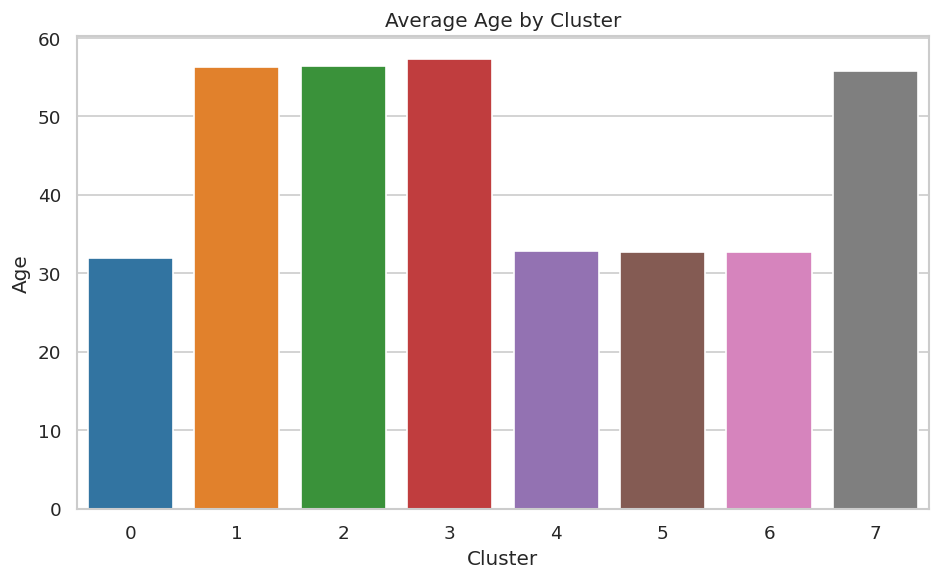

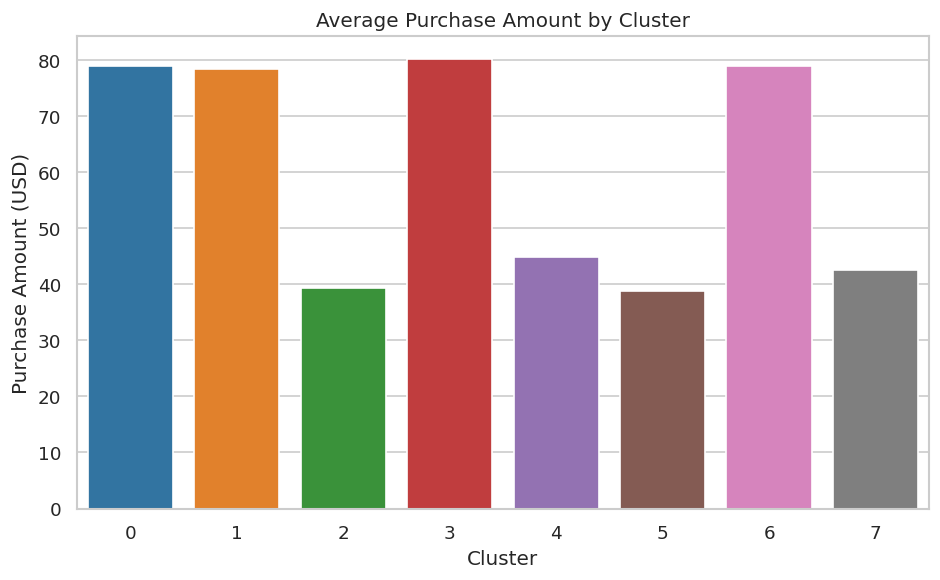

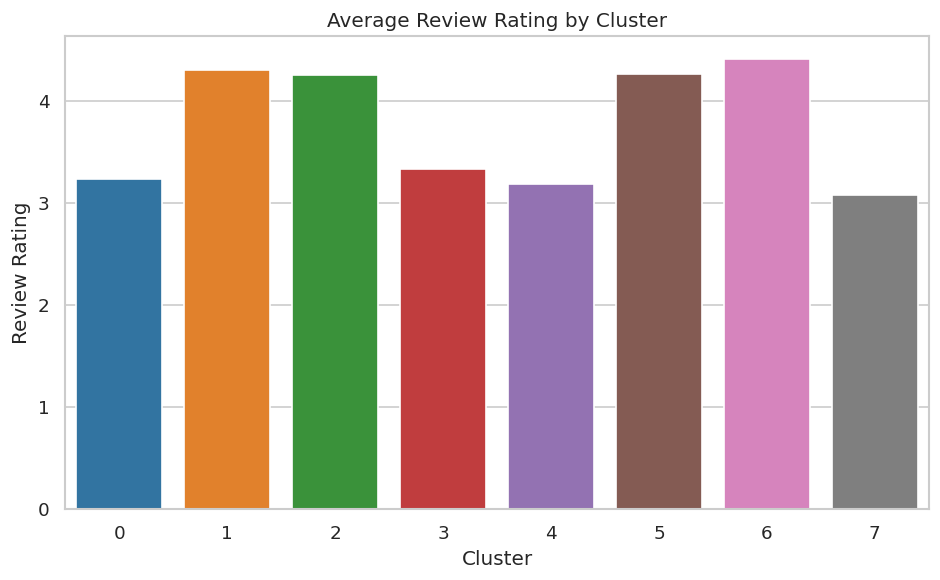

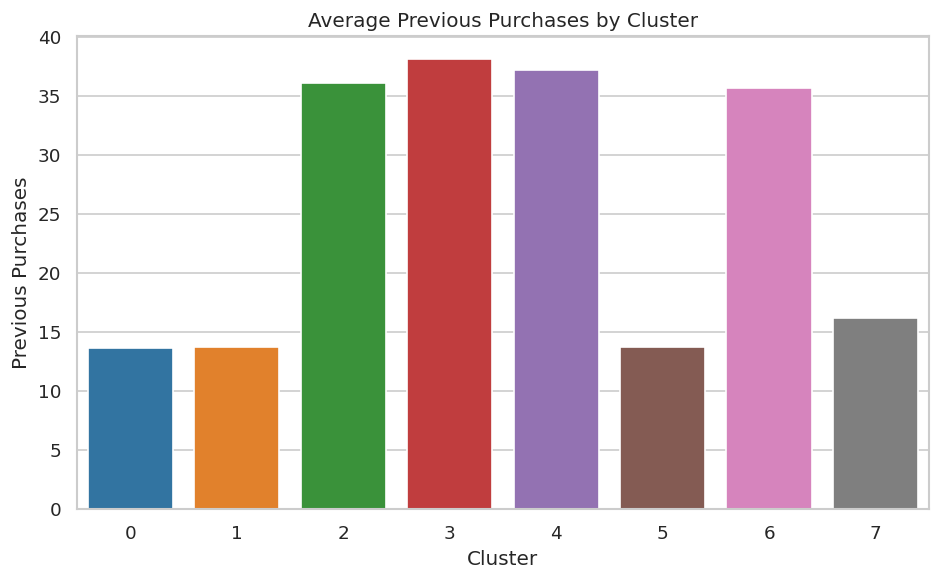

In [40]:
# ============================================================
# CELL 42 — CLUSTER PROFILE VISUALIZATIONS
# ============================================================

profile_columns = [
    (
        "Mean_Age",
        "Average Age by Cluster",
        "Age"
    ),
    (
        "Mean_Purchase_Amount",
        "Average Purchase Amount by Cluster",
        "Purchase Amount (USD)"
    ),
    (
        "Mean_Review_Rating",
        "Average Review Rating by Cluster",
        "Review Rating"
    ),
    (
        "Mean_Previous_Purchases",
        "Average Previous Purchases by Cluster",
        "Previous Purchases"
    )
]

for column, title, ylabel in profile_columns:

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=cluster_summary,
        x="KMeans_Cluster",
        y=column,
        hue="KMeans_Cluster",
        palette="tab10",
        legend=False
    )

    plt.title(title)
    plt.xlabel("Cluster")
    plt.ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [41]:
# ============================================================
# CELL 55 — FINAL RESEARCH SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("FINAL RESEARCH ANALYSIS SUMMARY")
print("=" * 80)

print("\nDATASET")
print("-" * 80)
print(f"Original observations : {ORIGINAL_SIZE}")
print(f"Analysis observations : {SAMPLE_SIZE}")
print(f"Sampling method       : {sampling_method}")

print("\nFEATURES")
print("-" * 80)

for feature in CLUSTER_FEATURES:
    print(f"- {feature}")

print("\nDATA QUALITY")
print("-" * 80)
print(
    "Missing values:",
    int(df.isnull().sum().sum())
)
print(
    "Duplicate rows:",
    int(df.duplicated().sum())
)

print("\nK-MEANS")
print("-" * 80)
print(
    "Selected k:",
    FINAL_K
)
print(
    "Silhouette score:",
    round(
        final_kmeans_silhouette,
        4
    )
)

print("\nHIERARCHICAL CLUSTERING")
print("-" * 80)
print(
    "Best k:",
    int(best_hierarchical["k"])
)
print(
    "Best silhouette:",
    round(
        best_hierarchical[
            "Silhouette Score"
        ],
        4
    )
)

print("\nDBSCAN")
print("-" * 80)

if len(valid_dbscan) > 0:

    print(
        "Best eps:",
        best_dbscan["eps"]
    )

    print(
        "Best min_samples:",
        int(
            best_dbscan[
                "min_samples"
            ]
        )
    )

    print(
        "Clusters:",
        int(
            best_dbscan[
                "Clusters"
            ]
        )
    )

    print(
        "Silhouette:",
        round(
            best_dbscan[
                "Silhouette"
            ],
            4
        )
    )

else:

    print(
        "No valid DBSCAN solution found."
    )

print("\nSTATISTICAL ANALYSIS")
print("-" * 80)

print("\nPearson correlations:")
display(
    pearson_results.round(4)
)

print("\nCluster profile:")
display(
    comprehensive_profile.round(2)
)

print("\nMODEL COMPARISON")
print("-" * 80)

display(
    model_comparison.sort_values(
        "Silhouette",
        ascending=False
    ).round(4)
)



FINAL RESEARCH ANALYSIS SUMMARY

DATASET
--------------------------------------------------------------------------------
Original observations : 3900
Analysis observations : 3000
Sampling method       : Random sampling without replacement

FEATURES
--------------------------------------------------------------------------------
- Age
- Purchase Amount (USD)
- Review Rating
- Previous Purchases

DATA QUALITY
--------------------------------------------------------------------------------
Missing values: 0
Duplicate rows: 0

K-MEANS
--------------------------------------------------------------------------------
Selected k: 8
Silhouette score: 0.2305

HIERARCHICAL CLUSTERING
--------------------------------------------------------------------------------
Best k: 9
Best silhouette: 0.1387

DBSCAN
--------------------------------------------------------------------------------
Best eps: 0.4
Best min_samples: 10
Clusters: 2
Silhouette: 0.8592

STATISTICAL ANALYSIS
-----------------------

,Predictor,Pearson r,p-value,Significant (α=0.05)
0,Age,-0.0158,0.3861,No
1,Review Rating,0.0282,0.1223,No
2,Previous Purchases,0.0010,0.9549,No



Cluster profile:


NameError: name 'comprehensive_profile' is not defined